<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Installing the xgboost library
!pip install xgboost

In [ ]:
# imports the necessary libraries for data manipulation
import numpy as np
import pandas as pd

# imports the necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# command to tell Python to actually display the graphs
%matplotlib inline

# imports the necessary library for statistical analysis
from scipy import stats
import scipy.stats as stats

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression

# To split the data and get different metric scores
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    StackingClassifier)

# To do hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To measure classification performance
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To import XGBClassifier from the xgboost library
from xgboost import XGBClassifier

# To define maximum number of columns to be displayed
pd.set_option("display.max_columns", None)

# To restrict the float value to 3 decimal places
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# to filter warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# to read the csv file referenced in the parenthesis
df_visa = pd.read_csv('/content/drive/MyDrive/Python Course/Module 6/Project/stock_data.csv')

In [ ]:
# to create a copy of the dataset to keep the original intact
df = df_visa.copy()

# **Overview of the Dataset**

In [ ]:
# returns the first 5 rows in the dataset.
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
# returns the last 5 rows in the dataset.
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [ ]:
# checks the number of rows and columns in the data
df.shape

(25480, 12)

In [ ]:
# checks the datatype of each column, the total rows and columns, and the memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# checks the statistical summary of both numerical and categorical variables
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# checks for duplicates in the data and sums them
df.duplicated().sum()

np.int64(0)

In [ ]:
# checks the total number of missing values in each column
print(df.isnull().sum())
# checks total number of missing values in the data
print(df.isnull().sum().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64
0


**Observations:**

* There are  25480 rows and  12 columns in the dataset.

* The dataset consists of numeric and string data. There are  9 columns with object-type data, 2 columns with integer-type data, and 1 column with float-type data.

* There are no duplicates in the dataset.

* There are no missing values in the dataset.

* Statistical summary:
  *   There are 6 continents represented in the data. Asia is the most common continent.
  *   There are 4 categories of level of education. Majority of the employees have a bachelor's degree
  *   Majority of the employees have job experience and most of them do not require job training.
  *   The companies were established between 1800 and 2016.
  *   There are 5 categories of region of employment in the dataset. Norteast has the highest representation.
  *   The prevailing wage ranges from 2.137 to 319219.27 with an average of 74455.815 The variation betwen the minimum and maximun value is large.
  *   There are 4 categories in the unit of wage. Majority of the unit are Year.
  *   There are 2 categories of the type of position (whether full- or part time). Majority of the positions are full time.
  *   Out of 25480 cases, 17018 were certified.

* The case_id column represents the ID of each visa application. This column would not be useful in the analysis hence it would be dropped.

* The object-type columns in the data will be converted to category to reduce the memory size and avoid errors or long runtimes in further analysis.

In [ ]:
# this code finds all the object-type columns and saves it in nthe variable cols
cols = df.select_dtypes(include='object').columns

In [ ]:
# this code converts the object-type columns to category
for col in cols:
    df[col] = df[col].astype('category')

In [ ]:
# this code drops the case_id column from the dataset
df.drop('case_id', axis=1, inplace=True)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
# checking the info to ensure the above edits have been effected
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


* There are now 11 columns in the dataset and all object-type columns have been converted to category.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

## Defining functions to create visualizations

In [ ]:
# this function creates a histogram and boxplot on the same scale
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# this function creates labeled barplots

def labelled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# this function creates stacked barplots
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis

### Distribution of employee's continent

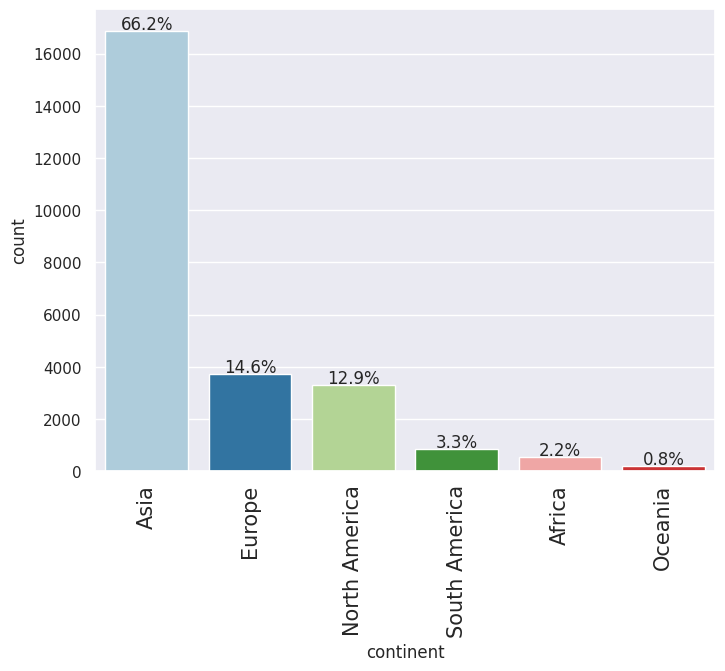

In [ ]:
# this code creates a labeled barplot to show the distribution of the employees' continent
labelled_barplot(df, 'continent', perc=True)

**Observations:**

* Majority of the applications (66.2%) came from Asia.
* Africa had the least number (2.2%) of applications.

### Distribution of education of employees

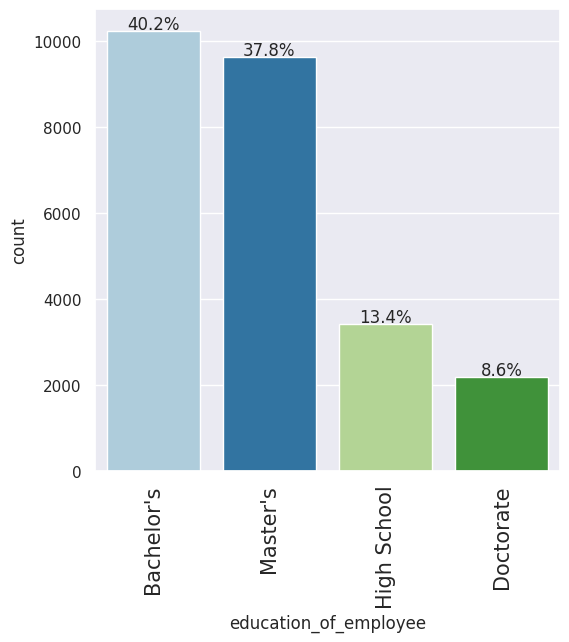

In [ ]:
# this code creates a labeled barplot to show the distribution of the level of education of the employees
labelled_barplot(df, 'education_of_employee', perc=True)

**Observations:**

* Majority of the candidates have a bachelor's degree (40.2%) or master's degree (37.8%).
* Few candidates (8.6%) have a doctorate.



### Distribution of job experience

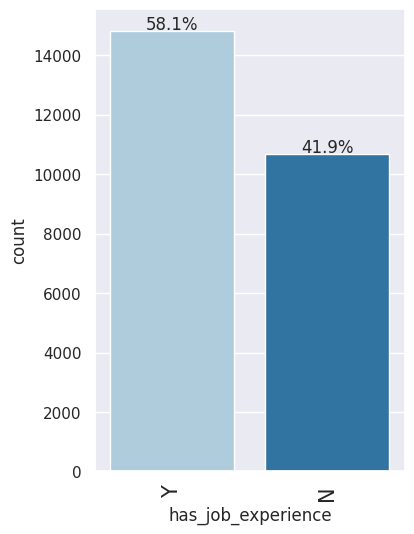

In [ ]:
# this code creates a labeled barplot to show the distribution of job experience
labelled_barplot(df, 'has_job_experience', perc=True)

**Observation:**

* 58.1%, which is more than half of the candidates have job experience.

### Distribution of required job training

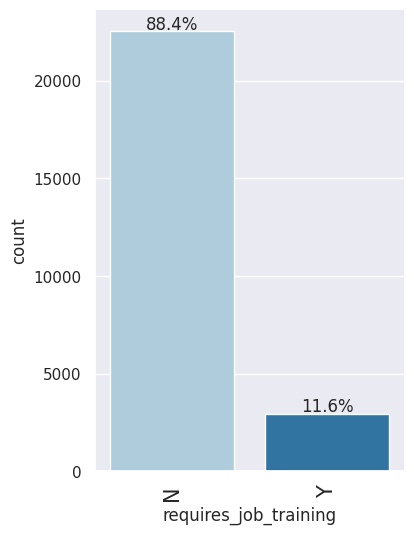

In [ ]:
# this code creates a labeled barplot to show the distribution of required job training
labelled_barplot(df, 'requires_job_training', perc=True)

**Observation:**

* 88.4% of candidates do not require job training.

* Probably due to the fact that they have job experience or the jobs may not require the candidates to receive any training.

### Distribution of number of employees

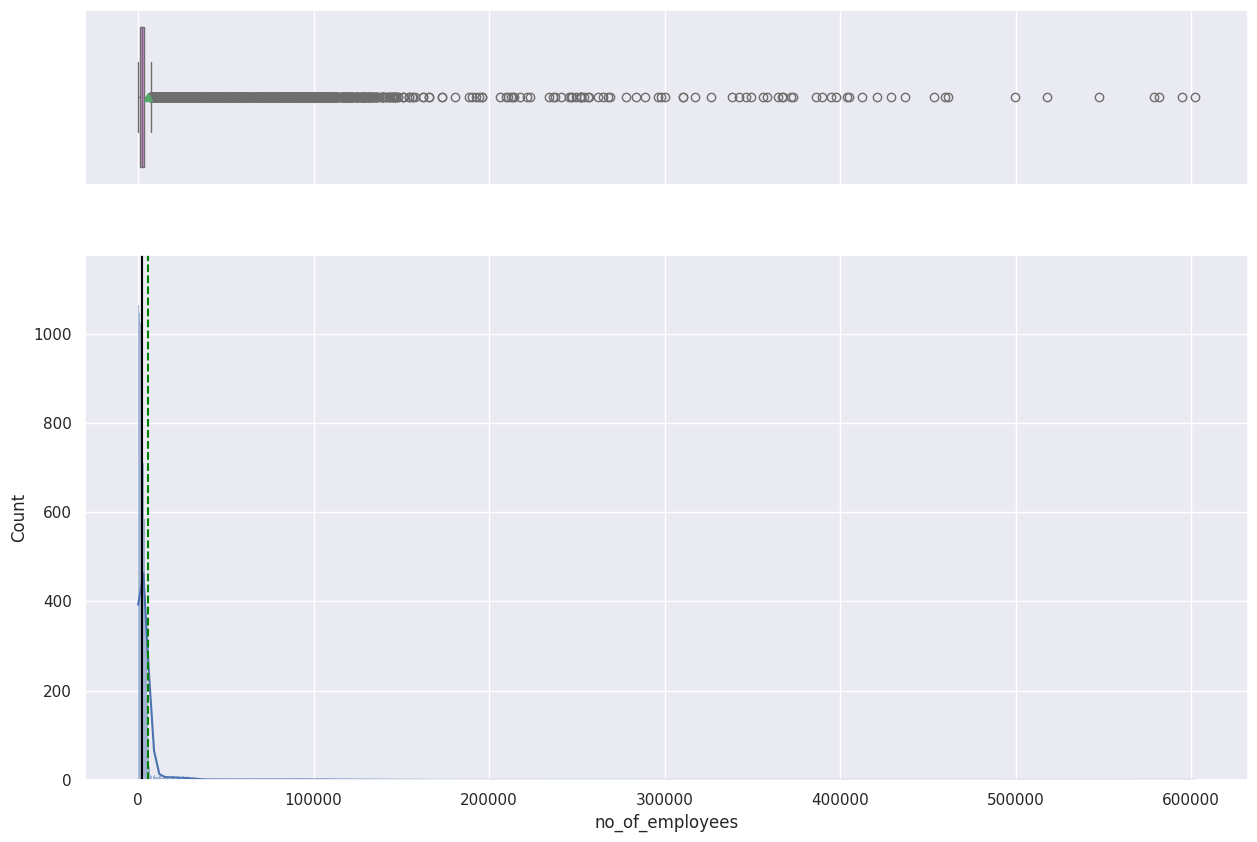

In [ ]:
# this code creates a histogram_boxplot to show the distribution of number of employees
histogram_boxplot(df, 'no_of_employees', kde=True)

* From the statisticaly summary, it was observed that the minimum value was negative.

* This gave an indication that there are negative values in the column for number of employees.

* These values would be converted to their absolute values.





In [ ]:
# this code checks all the negative values in the column for number of employees.
df.loc[df['no_of_employees'] < 0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.990,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.140,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.940,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.460,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.970,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.320,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.950,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.500,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.610,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.510,Year,Y,Certified


In [ ]:
# this code converts the negative values to their absolute values
df['no_of_employees'] = df['no_of_employees'].abs()

In [ ]:
# this code checks if the convertion was done
df.loc[df['no_of_employees'] < 0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


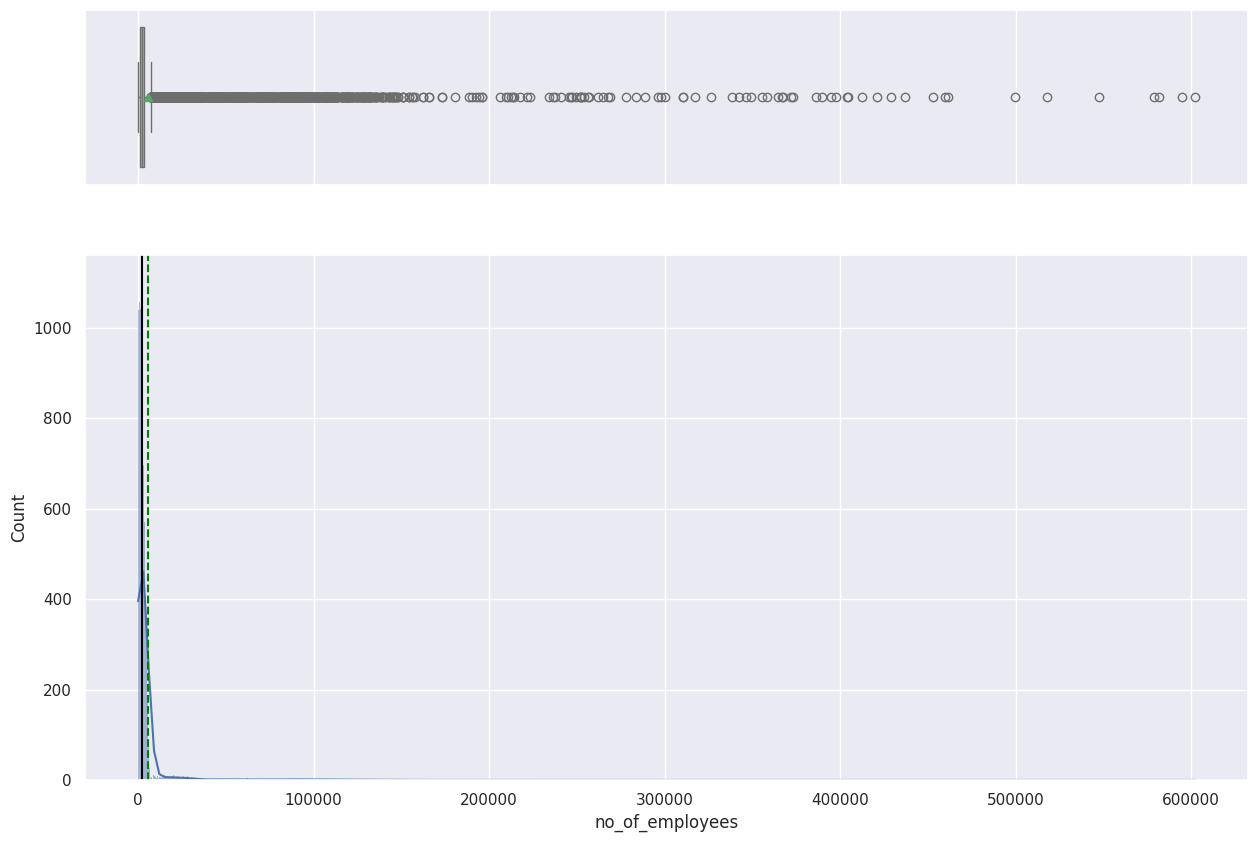

In [ ]:
# this code creates a histogram_boxplot to show the distribution of number of employees
histogram_boxplot(df, 'no_of_employees', kde=True)

**Observations:**

* There isn't much difference in the visaulizations for the data before and after converting the negative values.

* There are several outliers in the number of employees column.

* The distribution is right skewed.

### Distribution of year of establishment

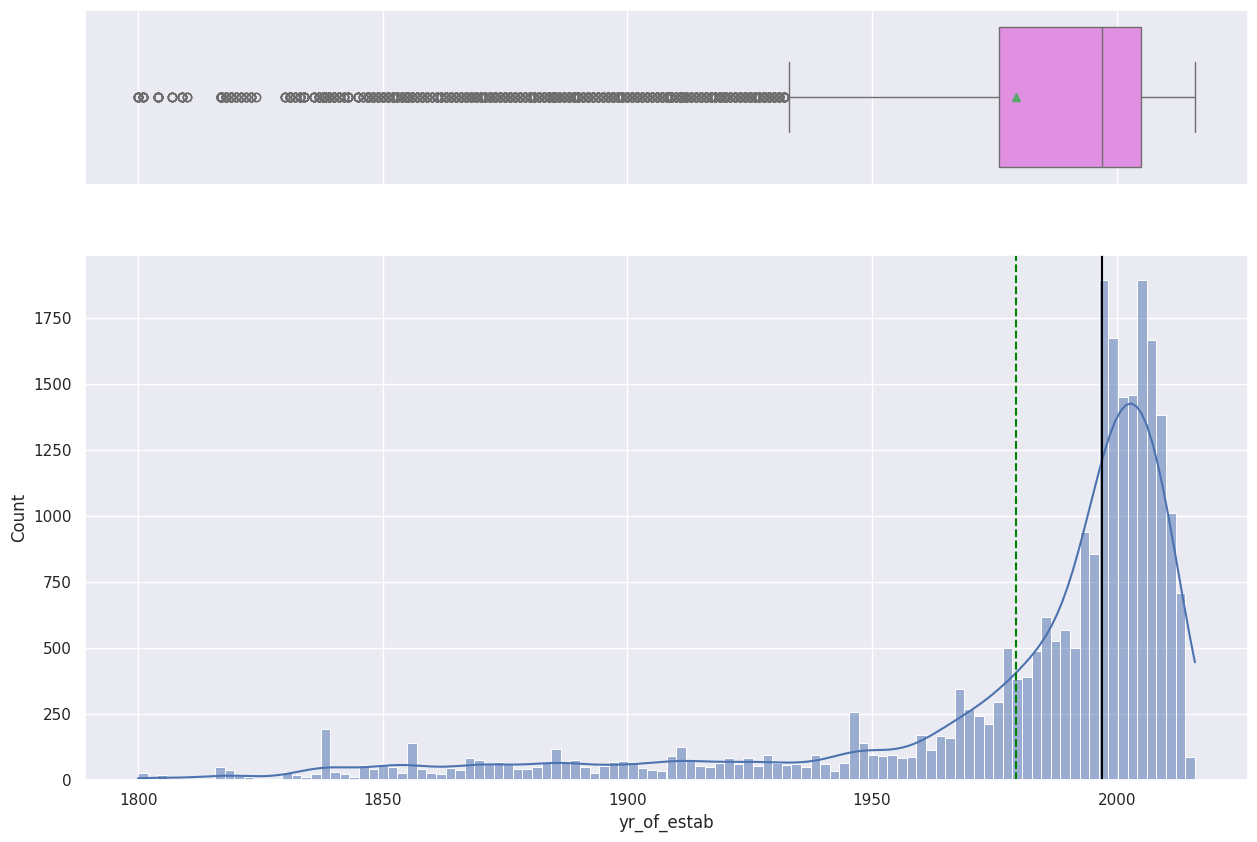

In [ ]:
# this code creates a histogram_boxplot to show the distribution of year of establishment
histogram_boxplot(df, 'yr_of_estab', kde=True)

**Observations:**

* The distribution is left skewed with the mean smaller than the median.

* There are several outliers on the lower end.

### Distribution of region of employment

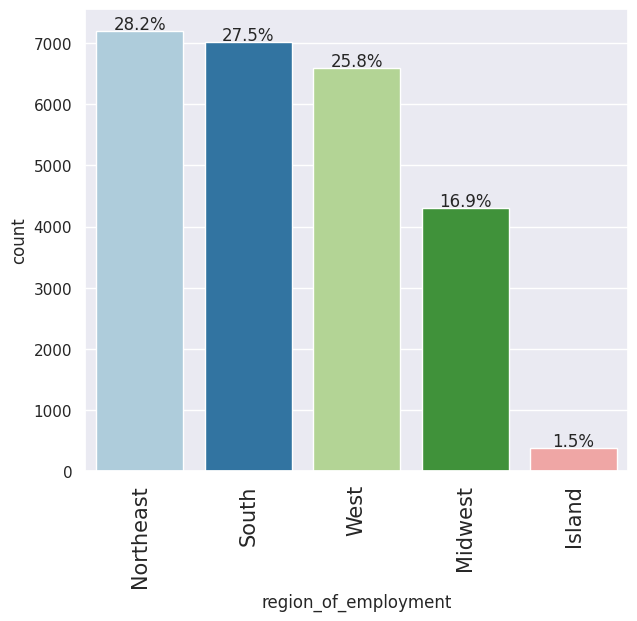

In [ ]:
# this code creates a labeled barplot to show the distribution of the region employment
labelled_barplot(df, 'region_of_employment', perc=True)

**Observations:**

* Majority of the applications came from the Northeast region (28.2%), followed closely by South (27.5%) and West (25.8%) regions.

* The region least represented in the dataset is Island (1.5%).

### Distribution of prevailing wage

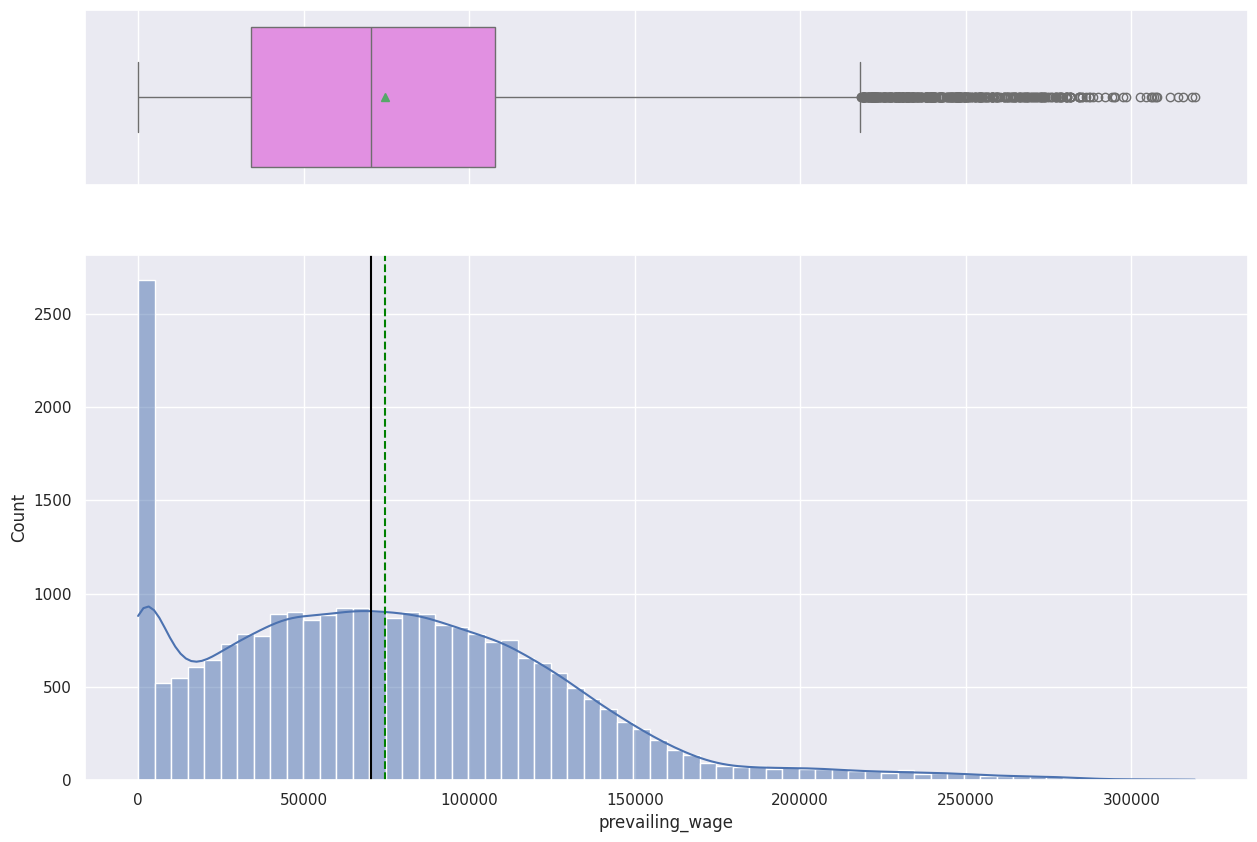

In [ ]:
# this code creates a histogram_boxplot to show the distribution of prevailing wage
histogram_boxplot(df, 'prevailing_wage', kde=True)

**Observations:**

* The distribution is right-skewed with a  mean higher than the median.

* There are several outliers on the higher end.

* From the statistical summary, a large variance was noted between the minimum and maximum values.



### Distribution of unit of wage

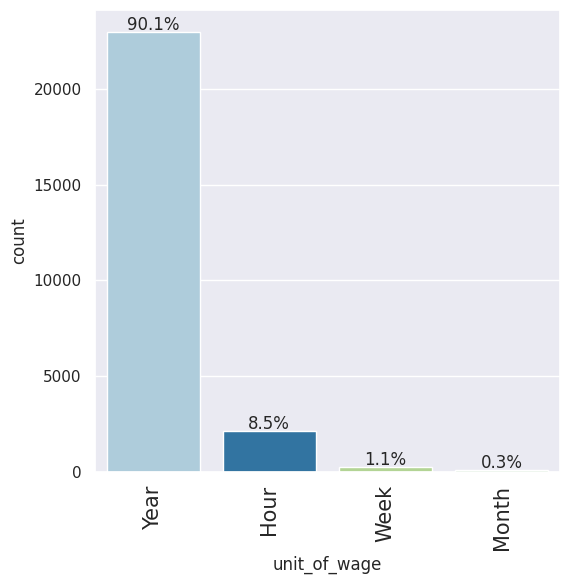

In [ ]:
# this code creates a labeled barplot to show the distribution of unit of wage
labelled_barplot(df, 'unit_of_wage', perc=True)

**Observation:**

* 90.1% of the wages are yearly.

* The variation between yearly and the other units of wage is wide.

* Monthly and weekly are the least.

### Distribution of type of position (full- or part time)

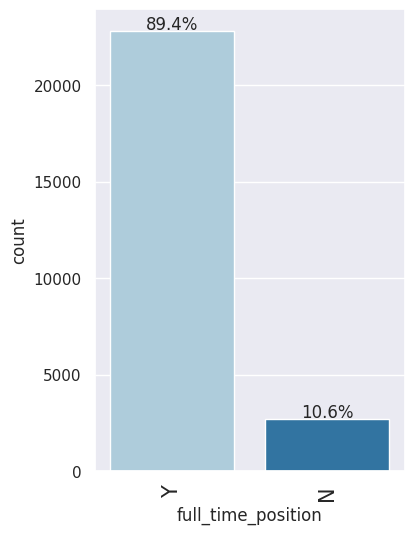

In [ ]:
# this code creates a labeled barplot to show the distribution of the type of position
labelled_barplot(df, 'full_time_position', perc=True)

**Observation:**

* 89.4% of the positions are full time.

### Distribution of visa case statuses

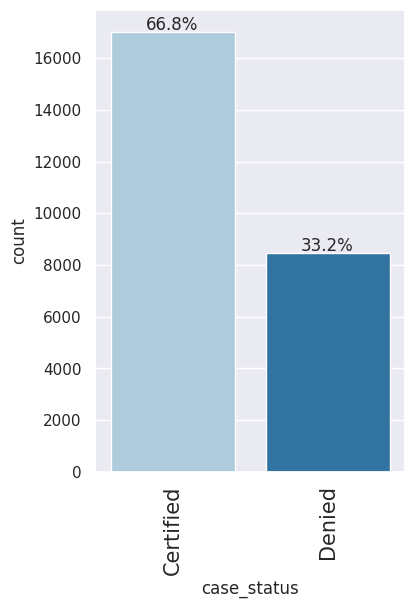

In [ ]:
# this code creates a labeled barplot to show the distribution of visa case status
labelled_barplot(df, 'case_status', perc=True)

**Observation:**

* Majority (66.8%) of the visas were certified.

## Bivariate Analysis

### Correlation of the variables

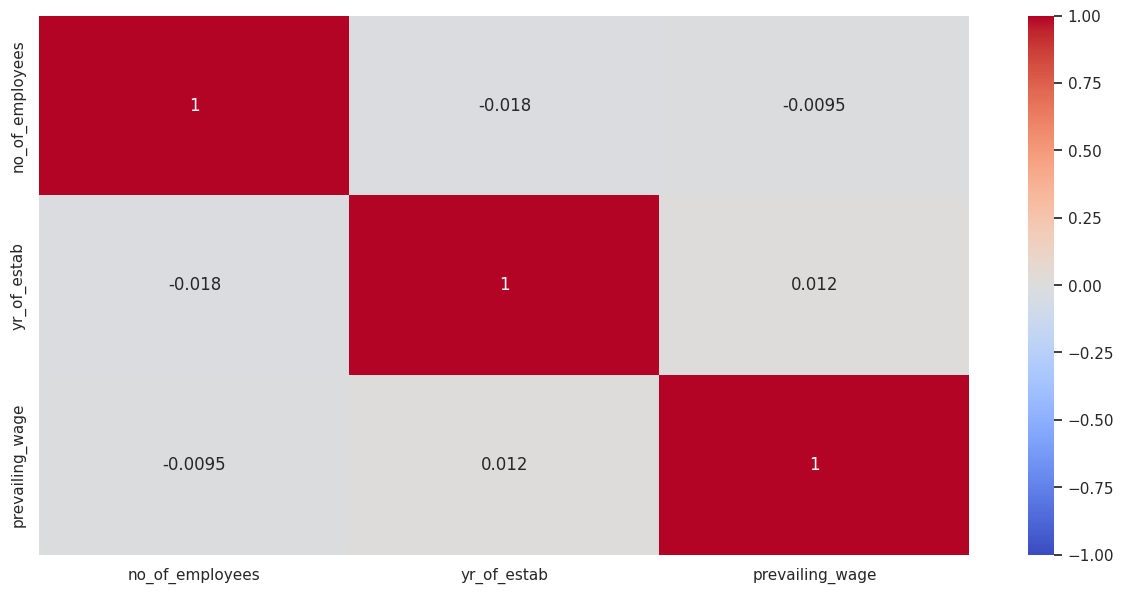

In [ ]:
# this code creates a plot with a size 15,7 and a heatmap of the dataframe df
plt.figure(figsize=(15, 7))

# select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.show()

**Observation:**

* There is no significan relationship between the numeric variables in the dataset.

### Impact of education level on visa approval

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


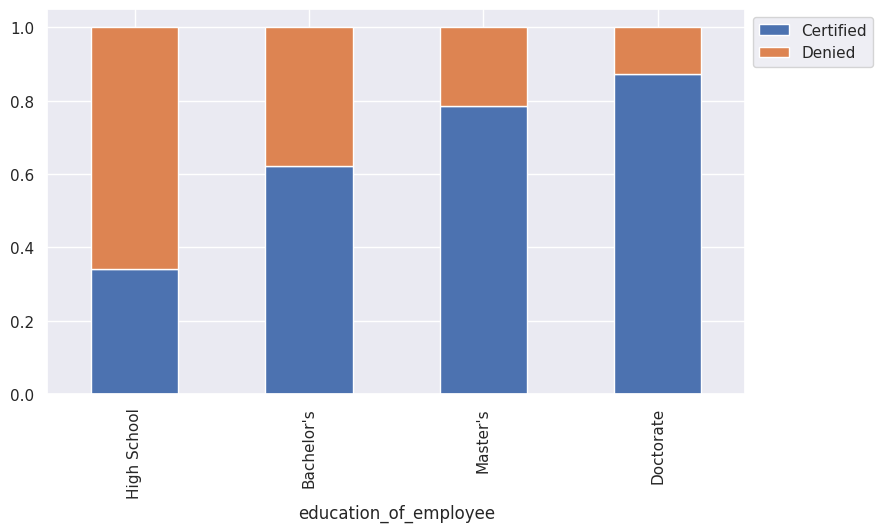

In [ ]:
# this code creates a stacked barplot of the level of education and case status
stacked_barplot(df, 'education_of_employee', 'case_status')

**Observations:**

* Visa approval rates are highest for candidates with a doctorate or master's degree.

* This indicates that the higher the level of education the more likely the visa would be approved.

* Candidates with a high school degree have the least chance of getting visa approvals.

### Visa approval rates and prior job experience

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


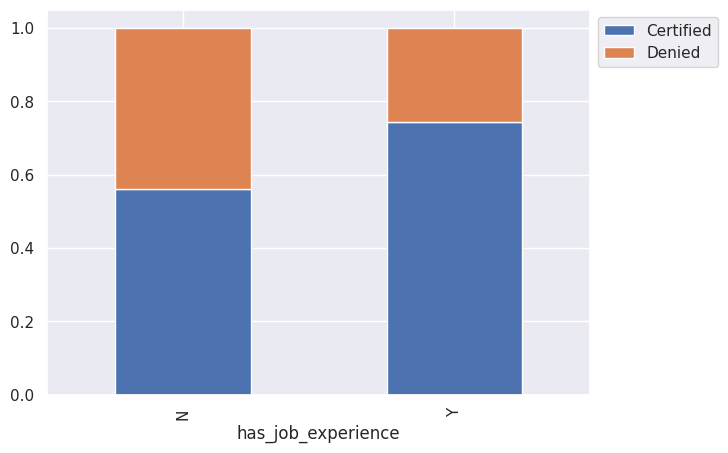

In [ ]:
# this code creates a stacked barplot of the job experience and case status
stacked_barplot(df, 'has_job_experience', 'case_status')

**Observation:**

* Candidates with prior job experience are slightly more likely to have their visas approved.

### Prevailing wage and visa approval

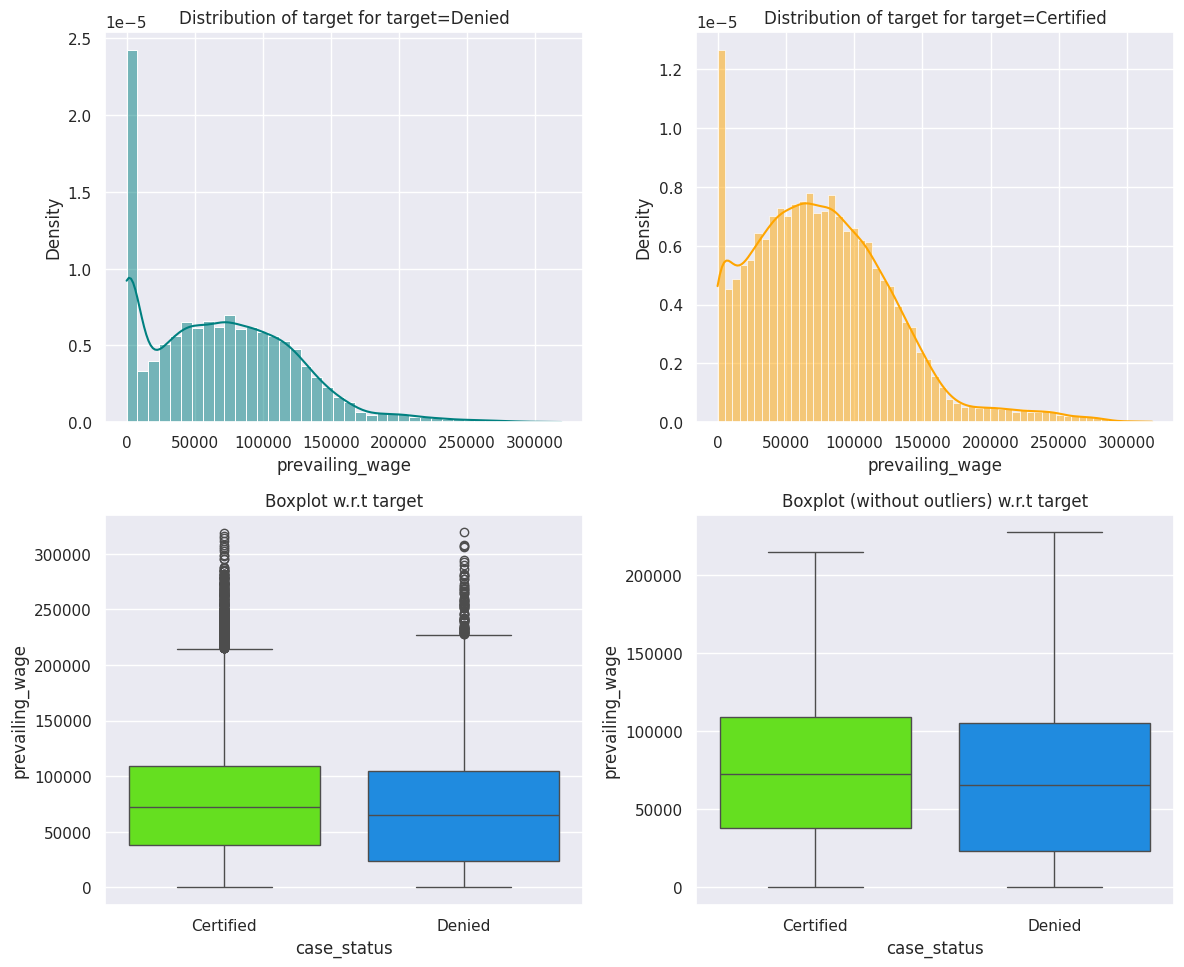

In [ ]:
# this code creates a plot of the prevailing wage and case status
distribution_plot_wrt_target(df, 'prevailing_wage', 'case_status')

**Observation:**

* The distributions of certified and denied visas in relation to prevailing wage may seem slightly identical (being slightl right skewed).

* However, the distribution for certified visa appears to have more and higher values than that of the denied visas.

* This suggests that higher wages may increase the candidates likelihood of a visa approval.

### Region of employment and visa approval

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


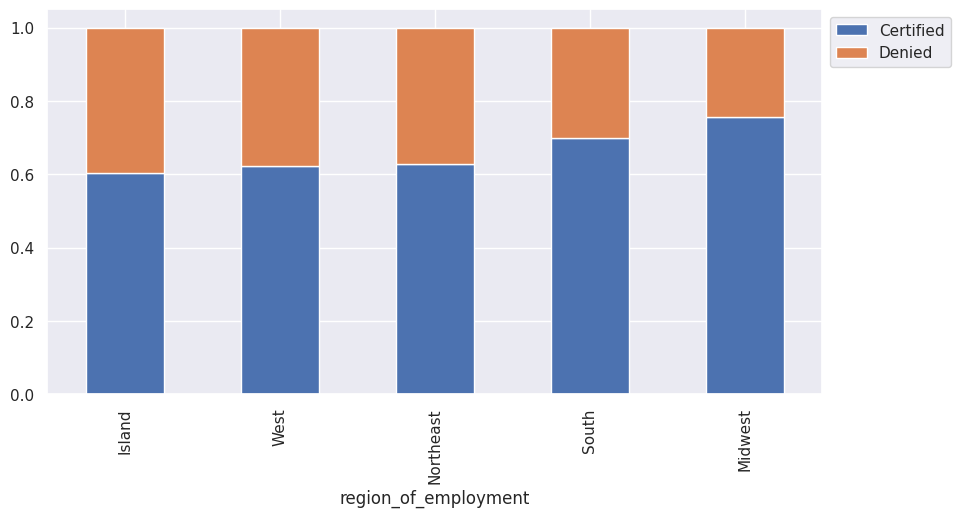

In [ ]:
# this code creates a stacked barplot of the region of employment and case status

stacked_barplot(df, 'region_of_employment', 'case_status')

**Observations**
* It appears that certain regions in the US have higher visa approval rates.

* The Midwest and South regions have higher visa approval rates compared to the other regions.

* The Northeast, West and Island regions have lower visa approval rates.

* The variance however, is not that wide.

### Number of employees and visa approval

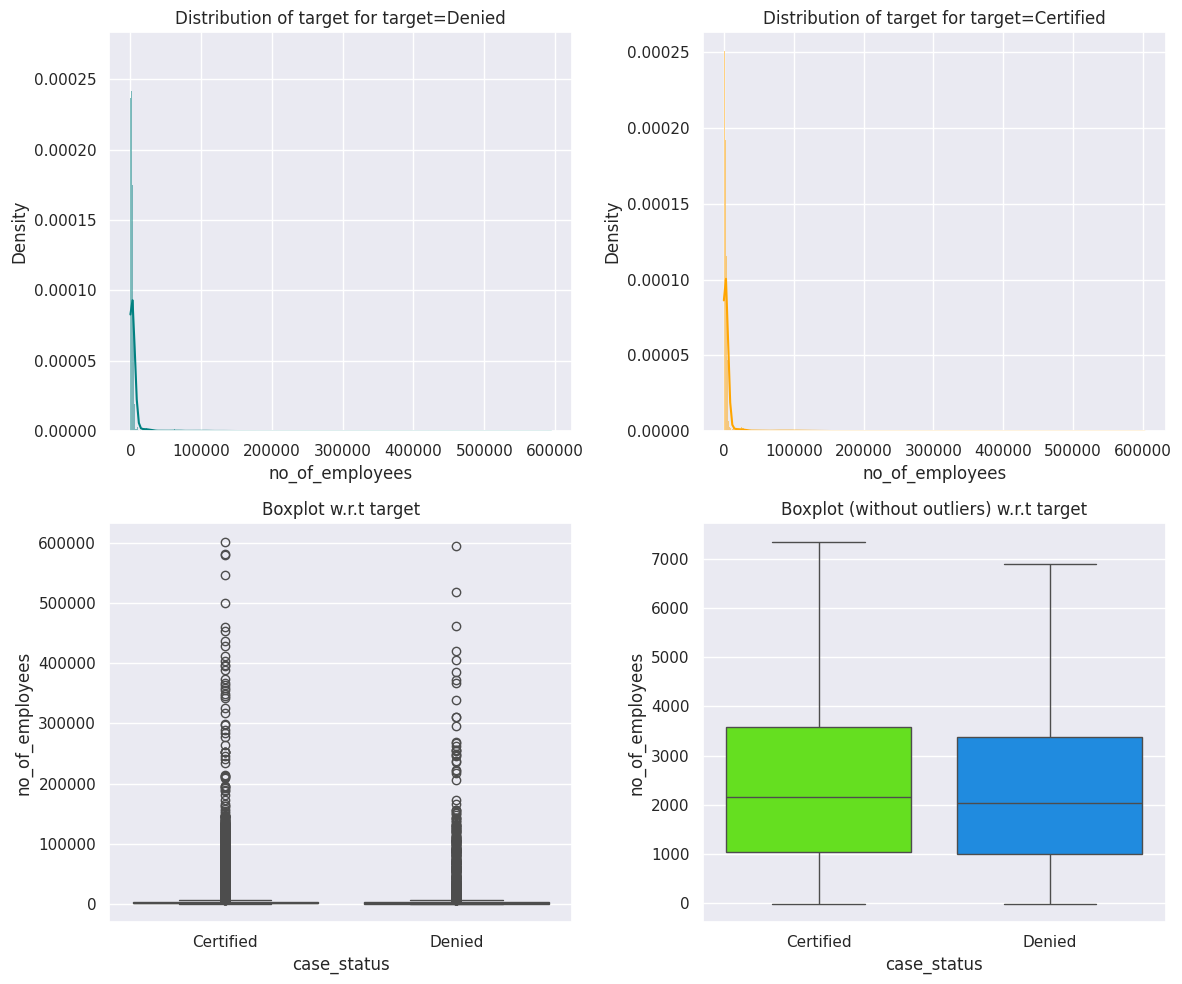

In [ ]:
# this code creates a plot of the number of employees and case status
distribution_plot_wrt_target(df, 'no_of_employees', 'case_status')

**Observations**:

* The distributions are highly right skewed for both certified and denied visas.

* There appears to be no indication of the impact of large companies on visa approval rates.

### Visa approval and continents

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


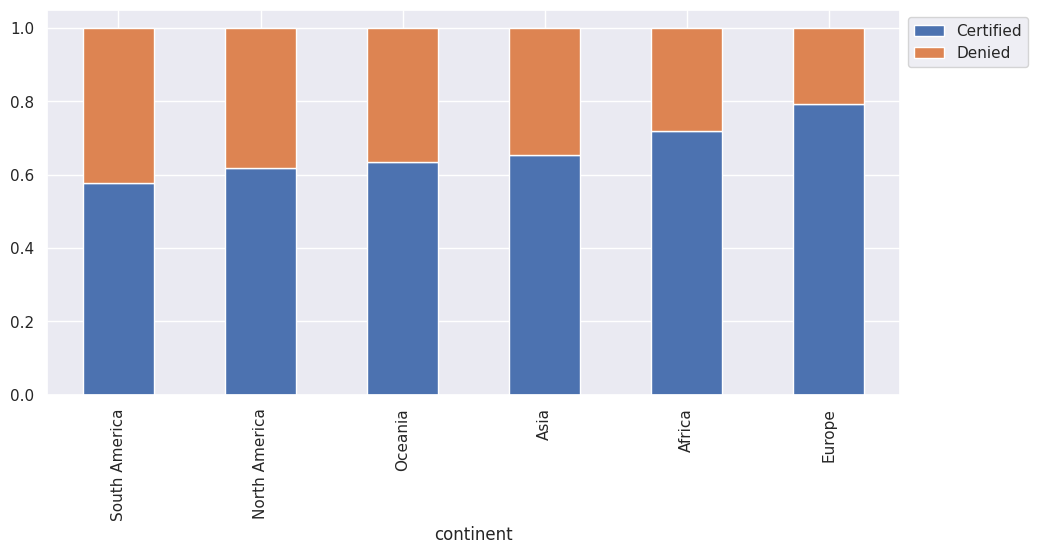

In [ ]:
# this code creates a stacked barplot of the continent and case status
stacked_barplot(df, 'continent', 'case_status')

**Observations**:

* Visa approval rates are different across various continents of employees.

* Europe have the highest visa approvals while South America has the lowest visa approval.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## Missing value treatment

There were no missing values in the dataset.



## Feature Engineering

* The case_ID was dropped earlier because it is not useful to the analysis.

* The obejct-type columns were converted to categorical to conserve the memory and prevent runtime delays and errors.

* The case_status will be converted from categorical to binary to make building the model easier.

* Hence, the certified visas will be represented as 1, while the denied visa represented as 0.

In [ ]:
# this code converts the case_status to binary
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,0
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,1
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,0
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,0
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,1


* From the statistical summary, the companies were establishment betweem 1800 and 2016.

* This indicates that 2016 is the highest year of establishment in the dataset.

* A new column - yrs_since_estab, will be added the yr_of_estab column will be dropped.

* This would be more informative for the model since it would capture the age of the company.

In [ ]:
# this code calculate the years since establishment, 2016 as the reference point
df['yrs_since_estab'] = 2016 - df['yr_of_estab']

# this code drops the 'yr_of_estab' column
df.drop('yr_of_estab', axis=1, inplace=True)

df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yrs_since_estab
0,Asia,High School,N,N,14513,West,592.203,Hour,Y,0,9
1,Asia,Master's,Y,N,2412,Northeast,83425.650,Year,Y,1,14
2,Asia,Bachelor's,N,Y,44444,West,122996.860,Year,Y,0,8
3,Asia,Bachelor's,N,N,98,West,83434.030,Year,Y,0,119
4,Africa,Master's,Y,N,1082,South,149907.390,Year,Y,1,11


## Outlier detection and treatment

In [ ]:
# this code creates a list of numeric columns and assigns it to the variable 'numeric_columns'
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

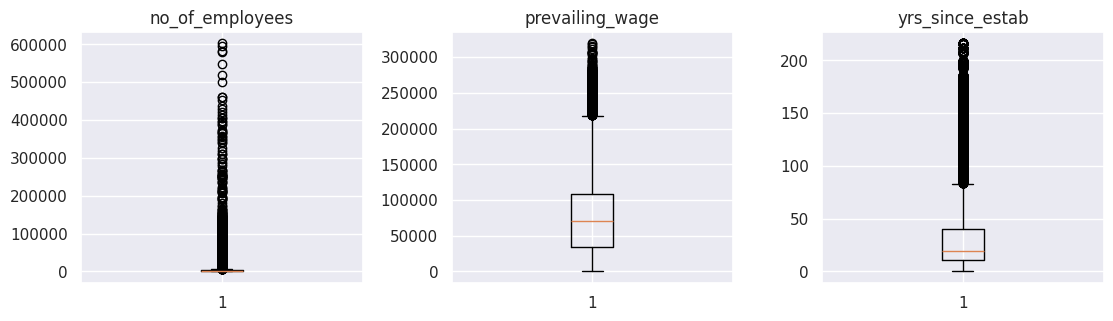

In [ ]:
# this code visualizes outliers using boxplots
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observation**:

* The distributions are right skewed.

* There appears to be weveral outliers int he data especially for the number of employees column.

* The outliers in the years since establishment column will not be treated. This is because, the older companies might represent valuable information for further analysis.

* The number of employees and prevailing wage columns will be treated to reduce the improve the preformance of the model to be built and reduce the effect of the outliers.

* Logarithmic transformation will be used because it is capable of normalizing the distribution while retaining the relative differences between the values.

### Outlier treatment

In [ ]:
# this code applies log transformation to 'no_of_employees'
df['no_of_employees'] = np.log1p(df['no_of_employees'])

# this code applies log transformation to 'prevailing_wage'
df['prevailing_wage'] = np.log1p(df['prevailing_wage'])

df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yrs_since_estab
0,Asia,High School,N,N,9.583,West,6.386,Hour,Y,0,9
1,Asia,Master's,Y,N,7.789,Northeast,11.332,Year,Y,1,14
2,Asia,Bachelor's,N,Y,10.702,West,11.720,Year,Y,0,8
3,Asia,Bachelor's,N,N,4.595,West,11.332,Year,Y,0,119
4,Africa,Master's,Y,N,6.987,South,11.918,Year,Y,1,11


The outliers will be visualized to see the effect of the treatment

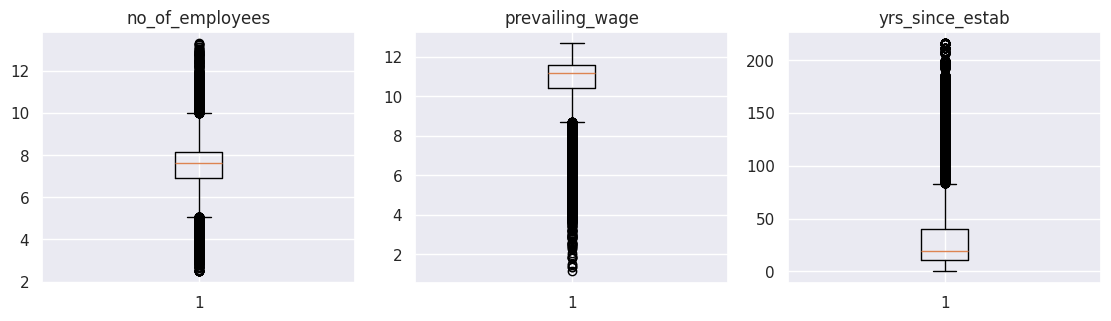

In [ ]:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(['no_of_employees', 'prevailing_wage', 'yrs_since_estab']):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

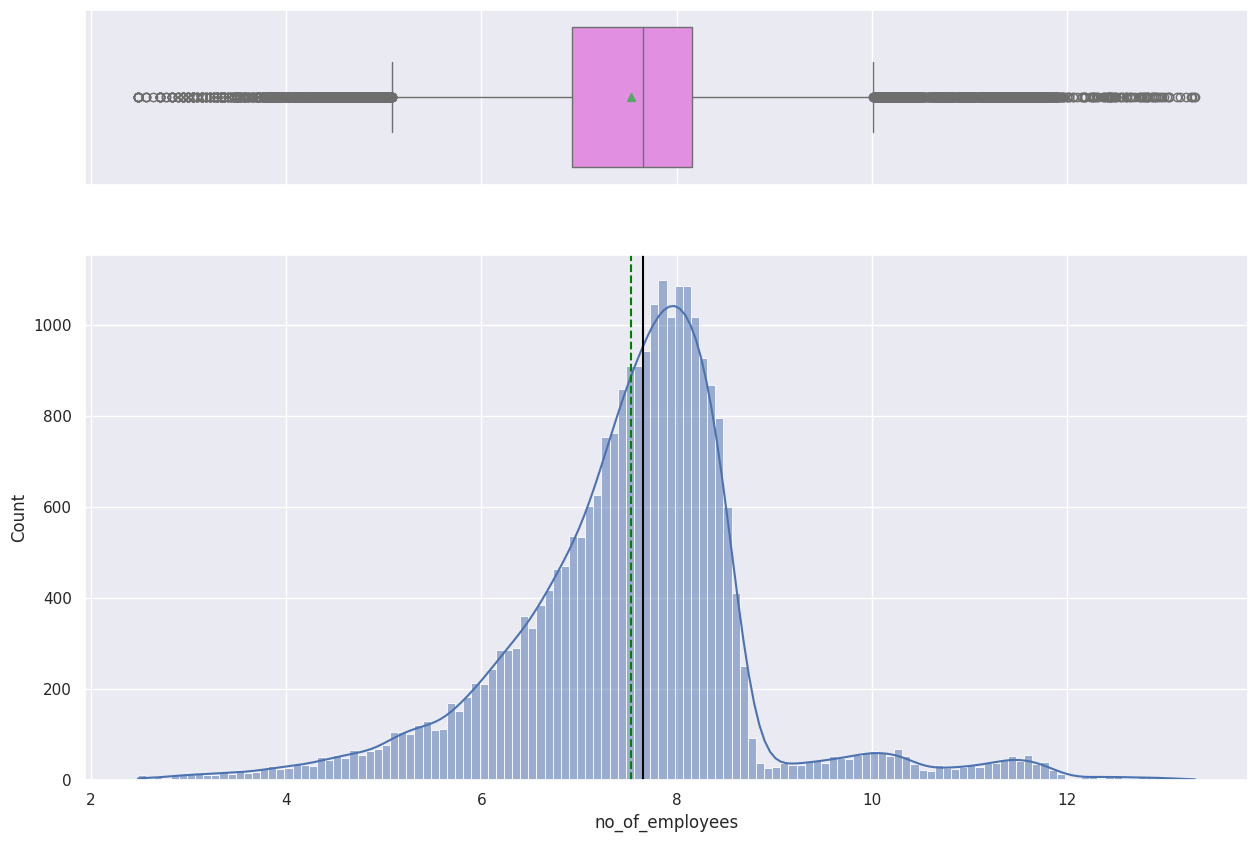

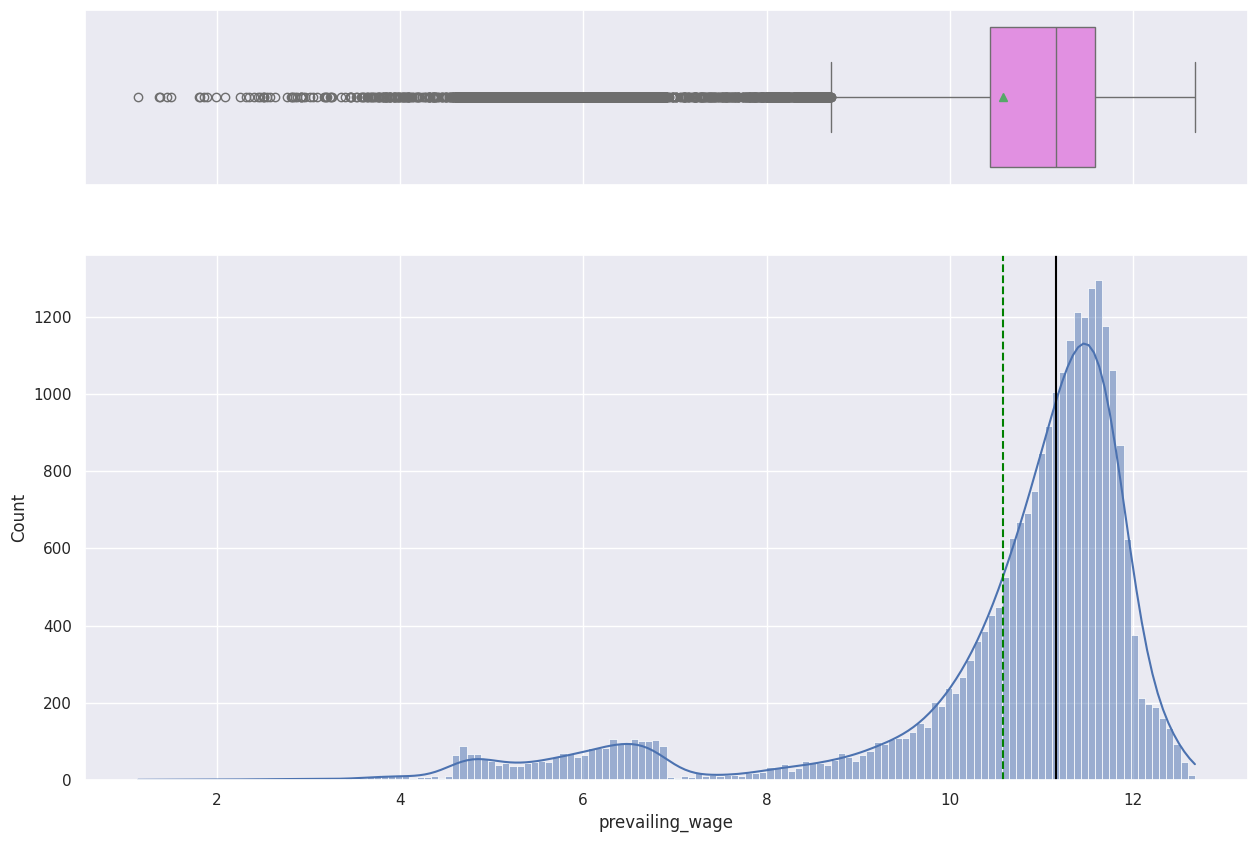

In [ ]:
histogram_boxplot(df, 'no_of_employees', kde=True)
histogram_boxplot(df, 'prevailing_wage', kde=True)

* The treatment has reduced the skewness of the distribution.

## Data preparation for modeling

In [ ]:
# this code defines the independent and dependent variables
X = df.drop(['case_status'], axis=1)
y = df['case_status']

print(X.head())
print()
print(y.head())

  continent education_of_employee has_job_experience requires_job_training  \
0      Asia           High School                  N                     N   
1      Asia              Master's                  Y                     N   
2      Asia            Bachelor's                  N                     Y   
3      Asia            Bachelor's                  N                     N   
4    Africa              Master's                  Y                     N   

   no_of_employees region_of_employment  prevailing_wage unit_of_wage  \
0            9.583                 West            6.386         Hour   
1            7.789            Northeast           11.332         Year   
2           10.702                 West           11.720         Year   
3            4.595                 West           11.332         Year   
4            6.987                South           11.918         Year   

  full_time_position  yrs_since_estab  
0                  Y                9  
1           

In [ ]:
# this code creates dummy variables and assigns it to the variable 'X'
X = pd.get_dummies(X, dtype=int, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)
X.head()

,no_of_employees,prevailing_wage,yrs_since_estab,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,9.583,6.386,9,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
1,7.789,11.332,14,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1
2,10.702,11.720,8,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1
3,4.595,11.332,119,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
4,6.987,11.918,11,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,1,1


In [ ]:
# this code splits the data into a train, validation and test set

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

In [ ]:
# this code prints the number of rows and percentage classes in the train and test set

print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print()
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print()
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print()
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 21)
Shape of the Validation set:  (5096, 21)
Shape of test set :  (5096, 21)

Percentage of classes in training set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64

Percentage of classes in validation set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64

Percentage of classes in test set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64


# **Model Building**

## Criterion for model evaluation

* It is important to note that the model can make wrong predictions - false positives and false negatives.

* That is, the model can predict a visa approval while in reality, it is a denial or the model can predict a visa denial while in reality, it is an approval.

* This implies that either a foreign candidate or a US citizen can be denied the opportunity of a job.

## Defining functions to check model performance

In [ ]:
# defining a function to compute different metrics to check performance of a classification model
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# defining a function to compute different metrics to check performance of a classification model
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# Defining a function to plot the confusion_matrix of a classification model using statsmodels

def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# Defining a function to compute different metrics to check performance of a classification model built using statsmodels

def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # Checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # Rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # To compute Accuracy
    recall = recall_score(target, pred)  # To compute Recall
    precision = precision_score(target, pred)  # To compute Precision
    f1 = f1_score(target, pred)  # To compute F1-score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

## Original data

### Model building

In [ ]:
# empty list to store all models
models = []

# this code appends the models to the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9894117647058823
Random forest: 1.0
GBM: 0.8291218182658106
Adaboost: 0.8204269947530306
dtree: 1.0

Validation Performance:

Bagging: 0.7735406277500734
Random forest: 0.8016319639842431
GBM: 0.826637008202419
Adaboost: 0.8180081855388813
dtree: 0.7422012948793408


In [ ]:
# this code prints the performance scores and difference between of the training and validation sets
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train)) # Changed to f1_score
    scores_val = f1_score(y_val, model.predict(X_val))       # Changed to f1_score
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9894, Validation Score: 0.7735, Difference: 0.2159
Random forest: Training Score: 1.0000, Validation Score: 0.8016, Difference: 0.1984
GBM: Training Score: 0.8291, Validation Score: 0.8266, Difference: 0.0025
Adaboost: Training Score: 0.8204, Validation Score: 0.8180, Difference: 0.0024
dtree: Training Score: 1.0000, Validation Score: 0.7422, Difference: 0.2578


**Observations**

* The f1_scores are smaller for GBM and Adaboost.

* For GBM, the validation f1_score is 0.8266 and training score is 0.8290. The difference between these two scores are small indicating a strong performance.

* For Adaboost, the validation f1_score is 0.8180 and training score is 0.8204. There is also a small difference between these two scores. This also indicates a strong performance.

## Oversampled data

### Model building

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 10210
Before Oversampling, counts of label 'Denied': 5078 

After Oversampling, counts of label 'Certified': 10210
After Oversampling, counts of label 'Denied': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
# empty list to store all models
models = []

# this code appends the models to the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9846777382364571
Random forest: 1.0
GBM: 0.7558145276776456
Adaboost: 0.726599629796388
dtree: 1.0

Validation Performance:

Bagging: 0.7433155080213903
Random forest: 0.7803337843933243
GBM: 0.7785359801488834
Adaboost: 0.7578914141414141
dtree: 0.7305279265493496


In [ ]:
# this code prints the performance scores and difference between of the training and validation sets
print("\n" "Training and Validation Performance Difference:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9847, Validation Score: 0.7433, Difference: 0.2414
Random forest: Training Score: 1.0000, Validation Score: 0.7803, Difference: 0.2197
GBM: Training Score: 0.7558, Validation Score: 0.7785, Difference: -0.0227
Adaboost: Training Score: 0.7266, Validation Score: 0.7579, Difference: -0.0313
dtree: Training Score: 1.0000, Validation Score: 0.7305, Difference: 0.2695


**Observations**

* The validation f1_scores for all the models decreased after training on the oversampled data. The SMOTE technique appears to not have made an improvement in the model for the validation set.

* The f1_scores and differences between validation and training set for GBM and Adaboost are still smaller than the other models.

* The differences between the validaton and training scores for GBM and Adaboost are negative values because the validation scores are higher.

* This seems to suggest that there is likely some underfitting on the oversampled training set.

* The Random Forest model has the highest validation f1_score with a larger difference between train and validation set (compared to the other models). This may be due to overfitting.

## Undersampled data

### Model building

In [ ]:
# this code performs random undersampling on the training data and reduces the number of samples
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Undersampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Undersampling, counts of label 'Certified': {}".format(sum(y_train_under == 1)))
print("After Undersampling, counts of label 'Denied': {} \n".format(sum(y_train_under == 0)))


print("After Undersampling, the shape of train_X: {}".format(X_train_under.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_under.shape))

Before Undersampling, counts of label 'Certified': 10210
Before Undersampling, counts of label 'Denied': 5078 

After Undersampling, counts of label 'Certified': 5078
After Undersampling, counts of label 'Denied': 5078 

After Undersampling, the shape of train_X: (10156, 21)
After Undersampling, the shape of train_y: (10156,) 



In [ ]:
# empty list to store all models
models = []

# this code appends the models to the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores = f1_score(y_train_under, model.predict(X_train_under))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9797627355198884
Random forest: 1.0
GBM: 0.7281441717791411
Adaboost: 0.7015343047380103
dtree: 1.0

Validation Performance:

Bagging: 0.7086773378264533
Random forest: 0.7415185783521809
GBM: 0.7767871109025497
Adaboost: 0.765990884802766
dtree: 0.6896551724137931


In [ ]:
# this code prints the performance scores and difference between of the training and validation sets
print("\n" "Training and Validation Performance Difference:" "\n")

for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores_train = f1_score(y_train_under, model.predict(X_train_under))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9798, Validation Score: 0.7087, Difference: 0.2711
Random forest: Training Score: 1.0000, Validation Score: 0.7415, Difference: 0.2585
GBM: Training Score: 0.7281, Validation Score: 0.7768, Difference: -0.0486
Adaboost: Training Score: 0.7015, Validation Score: 0.7660, Difference: -0.0645
dtree: Training Score: 1.0000, Validation Score: 0.6897, Difference: 0.3103


**Observations**

* The validation f1_scores for all the model decreased after training on the undersampled data. This also occured on the oversampled data.

* Undersampling did not improve the model.

* The f1_scores and differences between validation and training set for GBM and Adaboost are still lower than the other models and even lower than the original and oversampled data.

* The differences of the validaton and training scores for GBM and Adaboost are negative values because the validation scores are higher.

* This seems to suggest that there is likely underfitting on the undersampled training set.


# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


* Based on the results after building the model, GBM and AdaBoost proved to be the strongest models. Hence the hyperparameter tuning will be done for these two.

* In addition, the Random Forest will also be tuned. Due to the large gap between the train and validation scores, the goal will be to reduce the overfitting and improve the model.

## Hyperparameter tuning

### Gradient Boosting


In [ ]:
%%time

# this code defines the model
Model = GradientBoostingClassifier(random_state=1)

# this code is the parameter grid
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# this code defines the scoring method used to compare the parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# this code runs the RandomizedSearchCV
gbc_randomized_cv = RandomizedSearchCV(Model, param_grid, scoring=acc_scorer, cv=5)

# this code fits the parameters
gbc_randomized_cv.fit(X_train, y_train)

print("Best parameters: {}".format(gbc_randomized_cv.best_params_, gbc_randomized_cv.best_score_))

Best parameters: {'subsample': 0.9, 'n_estimators': np.int64(50), 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)}
CPU times: user 1min 7s, sys: 107 ms, total: 1min 7s
Wall time: 1min 18s


In [ ]:
# this code tunes the gradient boosting machine
gbm1_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1),
    random_state=1,
    subsample=1,
    n_estimators=50,
    max_features=0.5,
    learning_rate=0.1)

gbm1_tuned.fit(X_train, y_train)


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.5, n_estimators=50, random_state=1,
                           subsample=1)

### Checking model performance on training set

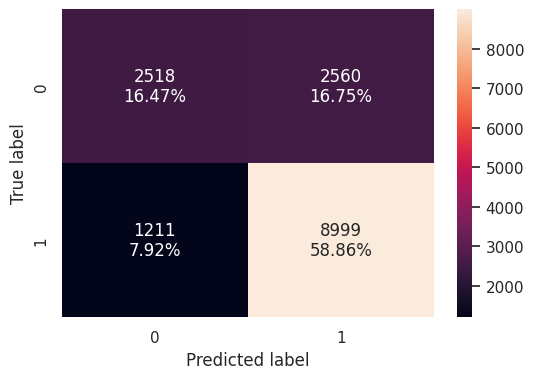

In [ ]:
# this code plots the confusion matrix for the Gradient Boosting Classifier on the training set
confusion_matrix_sklearn(gbc_randomized_cv.best_estimator_, X_train, y_train)

In [ ]:
# this code checks the performance metrics for the Gradient Boosting Classifier on the training set
gbc_train_perf = model_performance_classification_sklearn(gbc_randomized_cv.best_estimator_, X_train, y_train)
gbc_train_perf

,Accuracy,Recall,Precision,F1
0,0.753,0.881,0.779,0.827


### Checking model performance on validation set

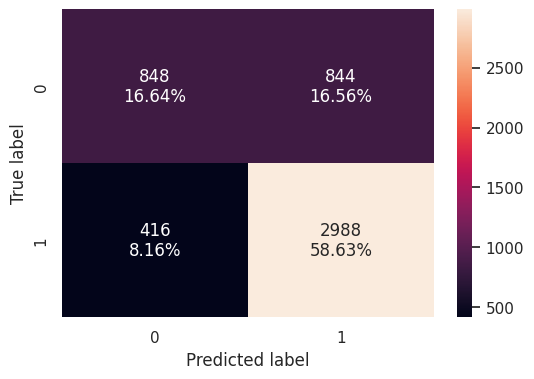

In [ ]:
# this code plots the confusion matrix for GBC on the validation set
confusion_matrix_sklearn(gbc_randomized_cv.best_estimator_, X_val, y_val)

In [ ]:
# # this code checks the performance metrics for the GBC on the validation set
gbc_val_perf = model_performance_classification_sklearn(gbc_randomized_cv.best_estimator_, X_val, y_val)
gbc_val_perf

,Accuracy,Recall,Precision,F1
0,0.753,0.878,0.780,0.826


### AdaBoost

In [ ]:
%%time

# this code selects the Adaboost classifier
abc_tuned = AdaBoostClassifier(random_state=1)

# this code is the parameter grid
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# this code defines the scoring method used to compare the parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# this code runs the RandomizedSearchCV
abc_randomized_cv = RandomizedSearchCV(abc_tuned, param_grid, scoring=acc_scorer, cv=5) # Corrected: used abc_tuned instead of Model

# this code fits the parameters
abc_randomized_cv.fit(X_train, y_train)

print("Best parameters: {}".format(abc_randomized_cv.best_params_))
print("Best score: {}".format(abc_randomized_cv.best_score_))

Best parameters: {'n_estimators': np.int64(100), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best score: 0.8226057775975499
CPU times: user 1min 42s, sys: 166 ms, total: 1min 42s
Wall time: 2min 4s


In [ ]:
# this code tunes the AdaBoost classifier
abc1_tuned = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
    learning_rate=0.1,
    n_estimators=100,
    random_state=1)
abc1_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=100, random_state=1)

### Checking model performance on training set

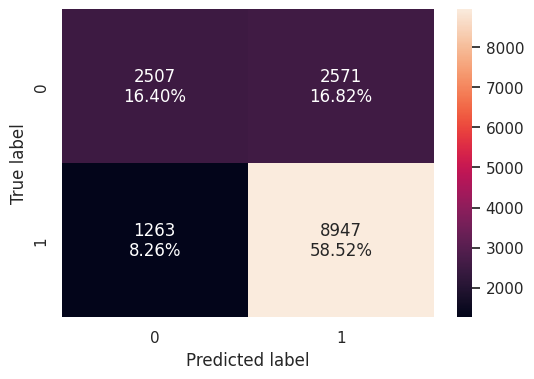

In [ ]:
# this code plots the confusion matrix for the AdaBoost Classifier on the training set
confusion_matrix_sklearn(abc_randomized_cv.best_estimator_, X_train, y_train)

In [ ]:
# this code checks the performance metrics for the AdaBoost Classifier on the training set
abc_train_perf = model_performance_classification_sklearn(abc_randomized_cv.best_estimator_, X_train, y_train)
abc_train_perf

,Accuracy,Recall,Precision,F1
0,0.749,0.876,0.777,0.824


### Checking model performance on validation set

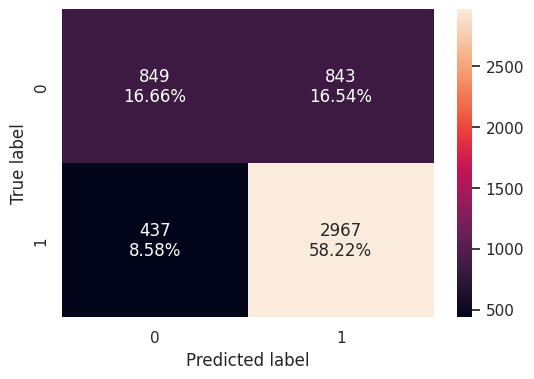

In [ ]:
# this code plots the confusion matrix for AdaBoost on the validation set
confusion_matrix_sklearn(abc_randomized_cv.best_estimator_, X_val, y_val)

In [ ]:
# # this code checks the performance metrics for the AdaBoost on the validation set
abc_val_perf = model_performance_classification_sklearn(abc_randomized_cv.best_estimator_, X_val, y_val)
abc_val_perf

,Accuracy,Recall,Precision,F1
0,0.749,0.872,0.779,0.823


### Random Forest

In [ ]:
%%time

# this code selects the Random Forest classifier
rfc_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

# this code is the parameter grid
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# this code defines the scoring method used to compare the parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# this code runs the RandomizedSearchCV
rfc_randomized_cv = RandomizedSearchCV(rfc_tuned, param_grid, scoring=acc_scorer, cv=5)

# this code fits the parameters
rfc_randomized_cv.fit(X_train, y_train)

print("Best parameters: {}".format(rfc_randomized_cv.best_params_))
print("Best score: {}".format(rfc_randomized_cv.best_score_))

Best parameters: {'n_estimators': 110, 'min_samples_leaf': np.int64(3), 'max_samples': np.float64(0.5), 'max_features': 'sqrt'}
Best score: 0.8221451908832126
CPU times: user 30.4 s, sys: 68.8 ms, total: 30.5 s
Wall time: 36.7 s


In [ ]:
# this code tunes the Random Forest Classifier
rdc1_tuned = RandomForestClassifier(
    n_estimators=110,
    min_samples_leaf=3,
    max_features='sqrt',
    max_samples=0.5,
    random_state=1
)
rdc1_tuned.fit(X_train, y_train)

RandomForestClassifier(max_samples=0.5, min_samples_leaf=3, n_estimators=110,
                       random_state=1)

### Checking model performance on training set

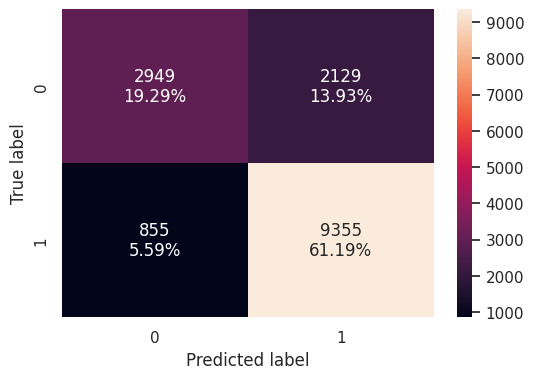

In [ ]:
# this code plots the confusion matrix for the Random Forest Classifier on the training set
confusion_matrix_sklearn(rfc_randomized_cv.best_estimator_, X_train, y_train)

In [ ]:
# this code checks the performance metrics for the Random Forest Classifier on the training set
rfc_train_perf = model_performance_classification_sklearn(rfc_randomized_cv.best_estimator_, X_train, y_train)
rfc_train_perf

,Accuracy,Recall,Precision,F1
0,0.805,0.916,0.815,0.862


### Checking model performance on validation set

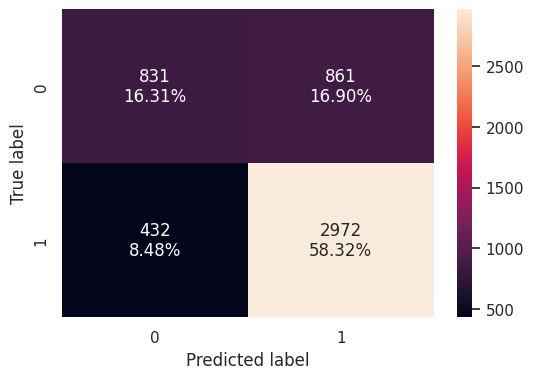

In [ ]:
# this code plots the confusion matrix for the Random Forest Classifier on the validation set
confusion_matrix_sklearn(rfc_randomized_cv.best_estimator_, X_val, y_val)

In [ ]:
# this code checks the performance metrics for the Random Forest Classifier on the validation set
rfc_val_perf = model_performance_classification_sklearn(rfc_randomized_cv.best_estimator_, X_val, y_val)
rfc_val_perf

,Accuracy,Recall,Precision,F1
0,0.746,0.873,0.775,0.821


***Observations**:

* Tuned Gradient Boosting Machine (GBM)

  * Training Performance: The tuned GBM had an Accuracy of 0.753, Recall of 0.881, Precision of 0.779, and an f1_score of 0.827 on the training set.
  
  * Validation Performance: On the validation set, it maintained a strong performance with an Accuracy of 0.753, Recall of 0.878, Precision of 0.780, and an f1_score of 0.826.
  
  * The f1_scores for both the training and validation sets are very close (0.827 vs. 0.826), indicating very good (even excellent) generalization.
  
  * The model is not overfitting and performs consistently on unseen data. This is a robust performance, slightly better or on par with the untuned validation score (0.8266).
  

* Tuned AdaBoost Classifier

  * Training Performance: The tuned AdaBoost model showed an Accuracy of 0.749, Recall of 0.876, Precision of 0.777, and an f1_score of 0.824 on the training set.
  
  * Validation Performance: The performance on the validation set was very similar, with an Accuracy of 0.749, Recall of 0.872, Precision of 0.779, and an f1_score of 0.823.

  * The tuned AdaBoost model has minimal difference between the training and validation f1_scores (0.824 vs. 0.823). This is similar to GBM.
  
  * The model has a low level of overfitting and a good generalization ability.
  
  * The AdaBoost model is as solid as the GBM.


* Tuned Random Forest Classifier

  * Training Performance: The tuned Random Forest model had an Accuracy of 0.805, Recall of 0.916, Precision of 0.815, and an f1_score of 0.862 on the training set.

  * Validation Performance: the performance on the validation set was comparatively lower with an Accuracy of 0.746, Recall of 0.873, Precision of 0.775, and an f1_score of 0.821.

  * The difference between the f1_scores for the training and validation sets is quite noticeable and larger in comparison with the GBM and AdaBoost models.

  * The tuning seemed to have made a slight improvement in the model to reduce the overfitting. However, there is likely some overfitting stil present.

All the three models had strong f1_scores on the validation set (above 0.82), which is good to address the issue of false positives and false negatives.

The top performing models are the Gradient Boosting Maching (GBM) and the AdaBoost.

With little variance in the scores on the training and validation sets, the GBM and the AdaBoost are excellent predictive models.


# **Model Comparison and Final Model Selection**

## Comparing all models

In [ ]:
# this code creates a summary table to compare the performance of the models on the train and validation sets
summary_train_perf = pd.concat([gbc_train_perf, abc_train_perf, rfc_train_perf], ignore_index=False)
summary_train_perf.index = ['GBM (Train)', 'AdaBoost (Train)', 'Random Forest (Train)']

summary_val_perf = pd.concat([gbc_val_perf, abc_val_perf, rfc_val_perf], ignore_index=False)
summary_val_perf.index = ['GBM (Validation)', 'AdaBoost (Validation)', 'Random Forest (Validation)']

performance_comparison_df = pd.concat([summary_train_perf, summary_val_perf])

print("Performance Comparison of Tuned Models:")

print(performance_comparison_df)

Performance Comparison of Tuned Models:
                            Accuracy  Recall  Precision    F1
GBM (Train)                    0.753   0.881      0.779 0.827
AdaBoost (Train)               0.749   0.876      0.777 0.824
Random Forest (Train)          0.805   0.916      0.815 0.862
GBM (Validation)               0.753   0.878      0.780 0.826
AdaBoost (Validation)          0.749   0.872      0.779 0.823
Random Forest (Validation)     0.746   0.873      0.775 0.821


In [ ]:
# this code checks the performance of the test set
gbc_test_perf = model_performance_classification_sklearn(gbc_randomized_cv.best_estimator_, X_test, y_test)
abc_test_perf = model_performance_classification_sklearn(abc_randomized_cv.best_estimator_, X_test, y_test)
rfc_test_perf = model_performance_classification_sklearn(rfc_randomized_cv.best_estimator_, X_test, y_test)

In [ ]:
# this code prints the performance of the test set
print('Gradient Boosting Test Performance' '\n',
      gbc_test_perf)
print()
print('AdaBoost Test Performance''\n',
      abc_test_perf)
print()
print('Randomized Forest Classifier Test Performance' '\n',
      rfc_test_perf)

Gradient Boosting Test Performance
    Accuracy  Recall  Precision    F1
0     0.743   0.877      0.770 0.820

AdaBoost Test Performance
    Accuracy  Recall  Precision    F1
0     0.740   0.875      0.768 0.818

Randomized Forest Classifier Test Performance
    Accuracy  Recall  Precision    F1
0     0.736   0.873      0.766 0.816


## Feature importance

In [ ]:
# this code selects and visualizes the final model
final_model = gbc_randomized_cv.best_estimator_

In [ ]:
# this code extract the feature importances from the final model
feature_importances = final_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(feature_importances)

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

print(importance_df.sort_values(by='Importance', ascending=False))

                              Feature  Importance
9   education_of_employee_High School       0.223
1                     prevailing_wage       0.162
11               has_job_experience_Y       0.150
10     education_of_employee_Master's       0.099
4                    continent_Europe       0.072
8     education_of_employee_Doctorate       0.056
5             continent_North America       0.047
13       region_of_employment_Midwest       0.031
19                  unit_of_wage_Year       0.024
16          region_of_employment_West       0.023
0                     no_of_employees       0.021
14     region_of_employment_Northeast       0.017
7             continent_South America       0.016
2                     yrs_since_estab       0.016
15         region_of_employment_South       0.015
12            requires_job_training_Y       0.013
3                      continent_Asia       0.010
20               full_time_position_Y       0.006
18                  unit_of_wage_Week       0.001


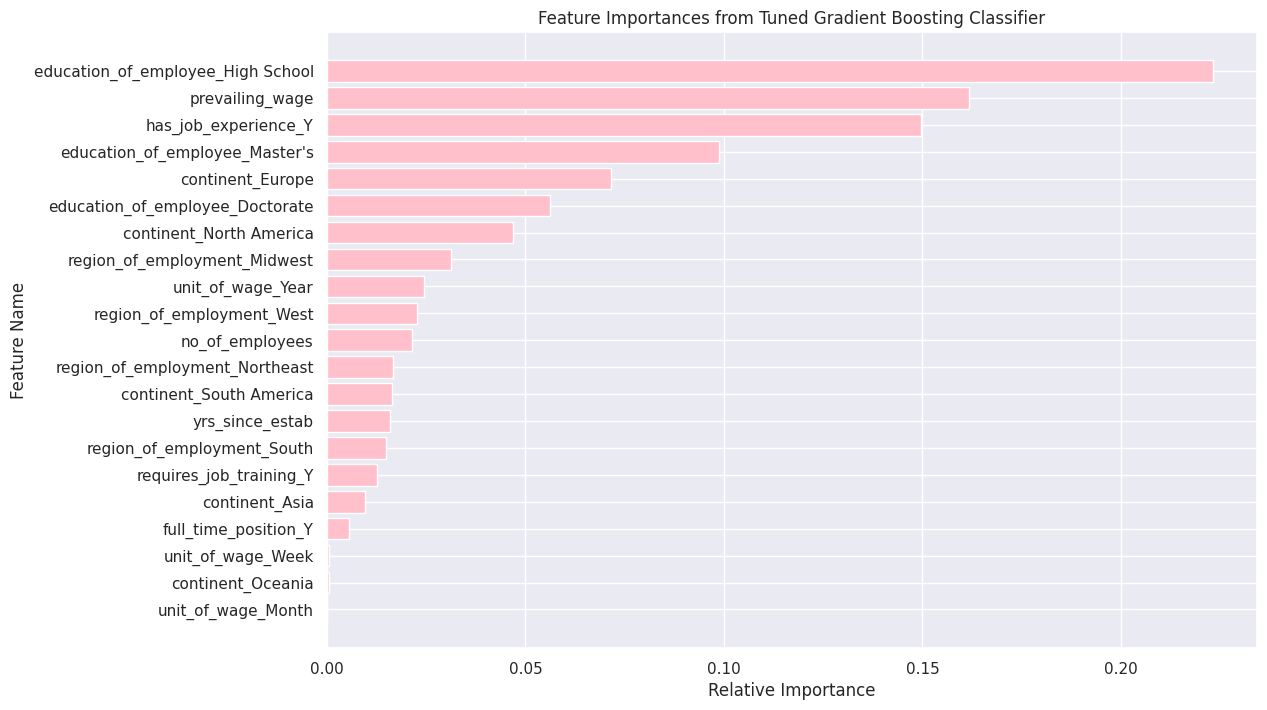

In [ ]:
# this code visualizes the feature importances
plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), feature_importances[indices], color='pink')
plt.title('Feature Importances from Tuned Gradient Boosting Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.yticks(range(len(indices)), feature_names[indices])
plt.show()

**Observations**:

* The most important feature is the High School level of education, followed by the Prevailing wage and the having prior job experience.

* These are the top three most important features.

* The least three important features are Unit of wage for week and month and Oceania continent.

# **Actionable Insights and Recommendations**

* The goal of this analysis was to reduce the workload associated wiith visa application reviews.
Specifically, the analysis sought to build a classification model to:
  1. Facilitate the process of visa approvals.
  2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

* The following factors (listed in no particular order) were observed to be associated with visa approvals (increased the likelihood of a visa approval):

  1. Having a doctorate or master's degree
  2. Having prior job experience
  3. Companies offering higher wages
  4. Candidates originating from the Midwest and South regions
  5. Candidates from the continent of Europe.

* These factors can be set as criteria to narrow applications that have a strong probability of getting an approval.
* It is important for the Office of Foreign Labor Certification (OFLC) to conduct its business without any form of discrimination.
* It is therefore recommended that since the important aspects of a job are having the required qualification, work experience, and prevailing wage, these three factors be on the top of the list of criteria when processing applications instead of region and continent of origin.
* Moreover, these are the same factors that appear as the important features in the selected final model.

* Three models were built to predict the likelihood of a visa being approved or denied.

* The Gradient Boosting Model was selected as the final model because it had better performance scores. Indicating a good predictive power and the ability to facilitate the process of visa approvals thereby improving efficiency of the OFLC.

___